Step 1: Import the Dataset

Before training a machine learning model, we first need to load the dataset into Python. The dataset is stored as a CSV (Comma-Separated Values) file. We use the Pandas library to read the CSV file and store it in a DataFrame called df, which makes it easy to view and manipulate the data.

In [12]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/processed_data.csv")

# Display the first five rows
df.head()

,sex,agegrp,rowtotal_17,rowtotal_18,rowtotal_20,high_illiteracy_risk,early_edu_rate,primary_rate,secondary_rate,slc_rate,...,attending_rate,ever_attending_rate,never_attending_rate,prov_1,prov_2,prov_3,prov_4,prov_5,prov_6,prov_7
0,1,5,144,134,144,1,1.000000,0.000000,0.0,0.0,...,0.930556,0.000000,0.069444,True,False,False,False,False,False,False
1,1,6,132,129,132,1,0.147287,0.852713,0.0,0.0,...,0.977273,0.000000,0.022727,True,False,False,False,False,False,False
2,1,7,122,119,122,1,0.042017,0.957983,0.0,0.0,...,0.975410,0.000000,0.024590,True,False,False,False,False,False,False
3,1,8,113,107,113,1,0.028037,0.971963,0.0,0.0,...,0.946903,0.000000,0.053097,True,False,False,False,False,False,False
4,1,9,127,125,127,0,0.000000,1.000000,0.0,0.0,...,0.960630,0.023622,0.015748,True,False,False,False,False,False,False


Step 2: Select Features and Target Variable

After loading the dataset, the next step is to separate the features (X) and the target variable (y).

Features (X) are the input variables that help the model make predictions. These include information such as age group, education rates, literacy rates, and province.
Target variable (y) is the output that the model will learn to predict. In this project, the target variable is high_illiteracy_risk, which indicates whether a local level is at high risk of illiteracy.

To create the feature set, we remove the target column from the dataset. The target column is then stored separately.

In [13]:
# Features (Independent Variables)
X = df.drop(columns=["high_illiteracy_risk", "never_attending_rate"])

# Target Variable (Dependent Variable)
y = df["high_illiteracy_risk"]

# Display the first five rows of the features
print(X.head())

# Display the first five values of the target variable
print(y.head())

   sex  agegrp  rowtotal_17  rowtotal_18  rowtotal_20  early_edu_rate  \
0    1       5          144          134          144        1.000000   
1    1       6          132          129          132        0.147287   
2    1       7          122          119          122        0.042017   
3    1       8          113          107          113        0.028037   
4    1       9          127          125          127        0.000000   

   primary_rate  secondary_rate  slc_rate  no_education_rate  attending_rate  \
0      0.000000             0.0       0.0                0.0        0.930556   
1      0.852713             0.0       0.0                0.0        0.977273   
2      0.957983             0.0       0.0                0.0        0.975410   
3      0.971963             0.0       0.0                0.0        0.946903   
4      1.000000             0.0       0.0                0.0        0.960630   

   ever_attending_rate  prov_1  prov_2  prov_3  prov_4  prov_5  prov_6  prov_7  

Step 3: Split the Dataset into Training and Testing Sets


Before training the Random Forest model, the dataset is divided into training and testing sets.

The training set is used to teach the model by allowing it to learn patterns from the data.
The testing set is used to evaluate how well the trained model performs on unseen data.

In this project, 80% of the data is used for training and 20% is used for testing. The random_state=42 parameter ensures that the split remains the same every time the code is run, making the results reproducible. The stratify=y parameter preserves the same proportion of each class in both the training and testing sets.

In [14]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shape of each dataset
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (14259, 19)
Testing Features: (3565, 19)
Training Labels: (14259,)
Testing Labels: (3565,)


Step 4: Train the Random Forest Model

After splitting the dataset into training and testing sets, the next step is to train the Random Forest Classifier.

Random Forest is a supervised machine learning algorithm that consists of multiple decision trees. Each tree is trained on different subsets of the data, and the final prediction is determined by combining the predictions of all trees through majority voting. This approach improves prediction accuracy and reduces the risk of overfitting.

In this project, the model is trained using the training dataset so it can learn the relationship between the input features and the target variable (high_illiteracy_risk).

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Step 5: Make Predictions


After training the Random Forest model, the next step is to use it to make predictions on the testing dataset. The model analyzes the input features in the testing set and predicts whether each local level belongs to the high illiteracy risk category or not.

These predicted values are stored in a new variable called y_pred. The predictions will be compared with the actual values in the next step to evaluate the model's performance.

In [16]:
# Make predictions using the testing dataset
y_pred = rf_model.predict(X_test)

# Display the first 10 predicted values
print("Predicted Values:")
print(y_pred[:10])

# Display the first 10 actual values
print("Actual Values:")
print(y_test.iloc[:10].values)

Predicted Values:
[0 1 0 1 1 0 0 0 1 1]
Actual Values:
[0 1 0 1 0 0 0 0 1 1]


Step 6: Evaluate the Model Performance

After making predictions, the final step is to evaluate how well the Random Forest model performed. Model evaluation compares the predicted values with the actual values from the testing dataset.

Several evaluation metrics are used:

Accuracy: Measures the overall percentage of correct predictions made by the model.
Precision: Indicates how many of the predicted positive cases were actually positive.
Recall: Measures how many of the actual positive cases were correctly identified by the model.
F1-Score: The harmonic mean of precision and recall, providing a balanced measure of model performance.
Confusion Matrix: Displays the number of correct and incorrect predictions for each class, helping to identify the types of errors made by the model.

These metrics provide a comprehensive evaluation of the Random Forest classifier.

Accuracy: 0.9225806451612903
Precision: 0.9434628975265018
Recall: 0.898989898989899
F1-Score: 0.9206896551724137

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      1783
           1       0.94      0.90      0.92      1782

    accuracy                           0.92      3565
   macro avg       0.92      0.92      0.92      3565
weighted avg       0.92      0.92      0.92      3565


Confusion Matrix:
[[1687   96]
 [ 180 1602]]


<Figure size 600x500 with 0 Axes>

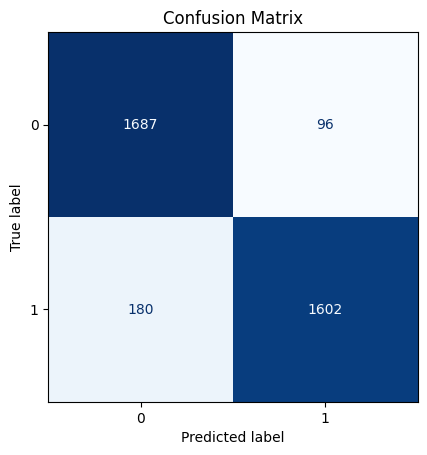

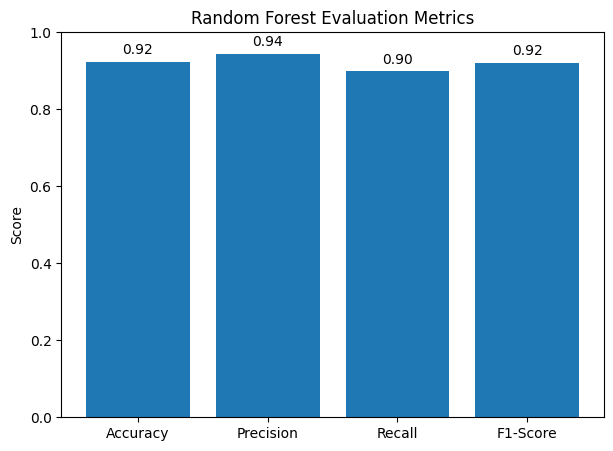

In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -------------------------
# Confusion Matrix Plot
# -------------------------
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

# -------------------------
# Evaluation Metrics Plot
# -------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(7,5))
plt.bar(metrics, scores)

plt.ylim(0, 1)

for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f"{score:.2f}", ha="center")

plt.ylabel("Score")
plt.title("Random Forest Evaluation Metrics")

plt.show()

Step 7: Analyze Feature Importance


One advantage of the Random Forest algorithm is that it can determine which features have the greatest influence on the model's predictions. This is known as feature importance.

By analyzing feature importance, we can identify which factors contribute the most to predicting high illiteracy risk. This information helps understand the key indicators affecting literacy outcomes and can support policymakers in making informed decisions.

                Feature  Importance
10       attending_rate    0.296037
5        early_edu_rate    0.129160
11  ever_attending_rate    0.105808
13               prov_2    0.090591
1                agegrp    0.078632
6          primary_rate    0.058524
4           rowtotal_20    0.052501
2           rowtotal_17    0.049437
3           rowtotal_18    0.042498
7        secondary_rate    0.040967
9     no_education_rate    0.009534
15               prov_4    0.008682
8              slc_rate    0.007581
16               prov_5    0.005778
0                   sex    0.005598
14               prov_3    0.004734
18               prov_7    0.004682
17               prov_6    0.004667
12               prov_1    0.004591


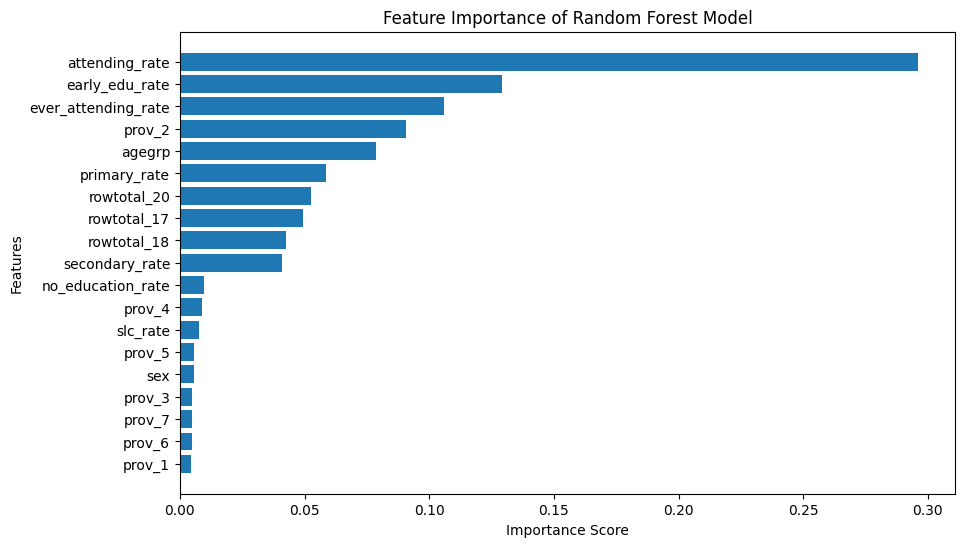

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame to display feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance in descending order
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the feature importance
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance of Random Forest Model")

# Show the most important feature at the top
plt.gca().invert_yaxis()

plt.show()

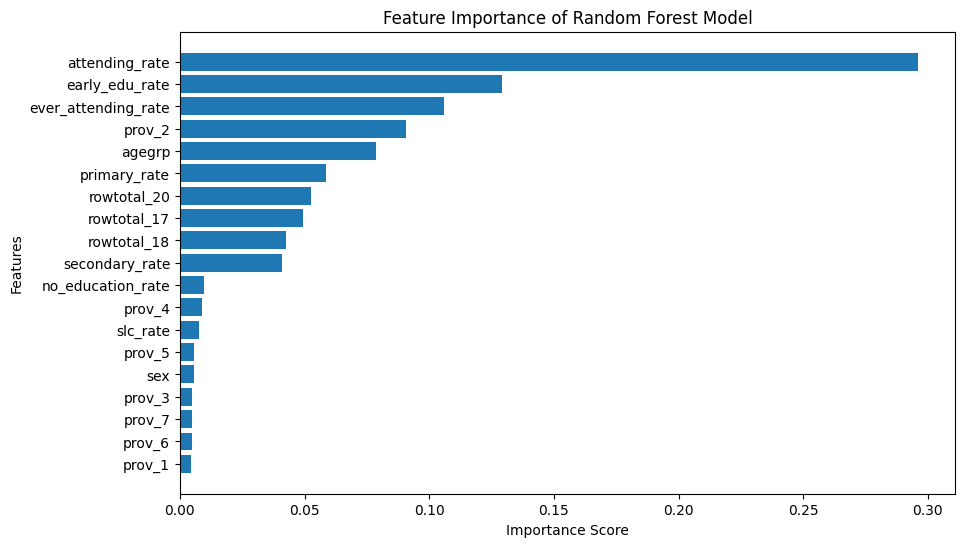

In [19]:
import matplotlib.pyplot as plt

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance of Random Forest Model")

# Show the most important feature at the top
plt.gca().invert_yaxis()

plt.show()